# NLLB-200 Fine-tuning for Legal Nepali-English Translation

**Model:** facebook/nllb-200-distilled-600M  
**Configurations:** 3 (NE→EN, EN→NE, Bidirectional)  
**Dataset:** Low-resource legal domain (~5K pairs)

## Setup
1. Runtime → **A100 GPU** + **High RAM**
2. Ensure data exists at: `/MyDrive/Legal_NLP/data/splits/`
3. Run all cells sequentially

**Models saved to:** `/content/models/` (local runtime)  
**Metrics saved to:** `/MyDrive/Legal_NLP/results/nllb/` (persistent)

---

## Cell 1: Environment Setup

In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install packages
print("Installing packages...")
!pip install -q torch transformers datasets sentencepiece
!pip install -q pandas numpy scikit-learn

# Check GPU
import torch
print(f"\n{'='*60}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️ WARNING: No GPU! Enable GPU runtime.")
print(f"{'='*60}")

# Set paths
DRIVE_BASE = '/content/drive/MyDrive/Legal_NLP'

# Create directories
import os
os.makedirs(f"{DRIVE_BASE}/results/nllb/metrics", exist_ok=True)
os.makedirs("/content/models", exist_ok=True)

print(f"\n✅ Setup complete!")
print(f"Data: {DRIVE_BASE}/data/splits/")
print(f"Results: {DRIVE_BASE}/results/nllb/")
print(f"Models: /content/models/ (local runtime only)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Installing packages...

GPU Available: True
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.5 GB

✅ Setup complete!
Data: /content/drive/MyDrive/Legal_NLP/data/splits/
Results: /content/drive/MyDrive/Legal_NLP/results/nllb/
Models: /content/models/ (local runtime only)


## Cell 2: Training Function (NLLB-200)

In [8]:
from transformers import (
    AutoModelForSeq2SeqLM, AutoTokenizer,
    get_constant_schedule_with_warmup
)
from transformers.optimization import Adafactor
from datasets import Dataset
import pandas as pd
import json
from datetime import datetime
import torch
import numpy as np
from tqdm import tqdm
import random

def train_nllb(direction, output_dir, train_data_path, val_data_path, resume_from_checkpoint=None):
    """
    Train NLLB-200 for legal translation using MANUAL training loop.
    (Seq2SeqTrainer has bugs with NLLB - manual loop works better)

    Args:
        direction: 'ne_en', 'en_ne', or 'bidirectional'
        output_dir: Local path to save checkpoints
        train_data_path: Path to train.csv
        val_data_path: Path to val.csv
        resume_from_checkpoint: Path to resume from (optional)
    """
    print("="*80)
    print(f"Training NLLB-200: {direction.upper()} (Manual Training Loop)")
    print(f"Output: {output_dir}")
    print("="*80)

    # Load model and tokenizer
    model_name = "facebook/nllb-200-distilled-600M"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if resume_from_checkpoint and os.path.exists(resume_from_checkpoint):
        print(f"Loading from checkpoint: {resume_from_checkpoint}")
        model = AutoModelForSeq2SeqLM.from_pretrained(resume_from_checkpoint)
    else:
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    model = model.cuda()
    print(f"Parameters: {model.num_parameters():,}")

    # Load data
    train_df = pd.read_csv(train_data_path)
    val_df = pd.read_csv(val_data_path)

    # Language codes for NLLB
    lang_codes = {'en': 'eng_Latn', 'ne': 'npi_Deva'}

    # Optimizer (using Adafactor like the working example)
    optimizer = Adafactor(
        [p for p in model.parameters() if p.requires_grad],
        scale_parameter=False,
        relative_step=False,
        lr=3e-5,
        clip_threshold=1.0,
        weight_decay=0.01,
    )
    scheduler = get_constant_schedule_with_warmup(optimizer, num_warmup_steps=200)

    # Training parameters
    batch_size = 4
    max_length = 128
    num_epochs = 6
    gradient_accumulation_steps = 8
    logging_steps = 50
    save_steps = 200

    total_steps = (len(train_df) // batch_size) * num_epochs

    print(f"\\nTraining config:")
    print(f"  Epochs: {num_epochs}")
    print(f"  Batch size: {batch_size}")
    print(f"  Gradient accumulation: {gradient_accumulation_steps}")
    print(f"  Total steps: {total_steps}")
    print(f"  Train samples: {len(train_df)}")
    print(f"  Val samples: {len(val_df)}")

    def get_batch(batch_size, data, direction_override=None):
        """Get a batch of translation pairs"""
        dir_to_use = direction_override if direction_override else direction

        if dir_to_use == 'ne_en':
            src_col, tgt_col = 'Nepali', 'English'
            src_lang, tgt_lang = lang_codes['ne'], lang_codes['en']
        elif dir_to_use == 'en_ne':
            src_col, tgt_col = 'English', 'Nepali'
            src_lang, tgt_lang = lang_codes['en'], lang_codes['ne']
        else:  # bidirectional - randomly choose direction
            if random.random() < 0.5:
                src_col, tgt_col = 'Nepali', 'English'
                src_lang, tgt_lang = lang_codes['ne'], lang_codes['en']
            else:
                src_col, tgt_col = 'English', 'Nepali'
                src_lang, tgt_lang = lang_codes['en'], lang_codes['ne']

        indices = random.sample(range(len(data)), min(batch_size, len(data)))
        sources = [str(data.iloc[i][src_col]) for i in indices]
        targets = [str(data.iloc[i][tgt_col]) for i in indices]

        return sources, targets, src_lang, tgt_lang

    # Training loop
    model.train()
    losses = []
    global_step = 0
    best_val_loss = float('inf')

    print("\\nStarting training...")

    for epoch in range(num_epochs):
        print(f"\\n{'='*80}")
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"{'='*80}")

        epoch_losses = []
        pbar = tqdm(range(len(train_df) // batch_size), desc=f"Epoch {epoch+1}")

        for step in pbar:
            try:
                # Get batch
                xx, yy, src_lang, tgt_lang = get_batch(batch_size, train_df)

                # Tokenize source
                tokenizer.src_lang = src_lang
                x = tokenizer(xx, return_tensors='pt', padding=True,
                            truncation=True, max_length=max_length).to(model.device)

                # Tokenize target
                tokenizer.src_lang = tgt_lang
                y = tokenizer(yy, return_tensors='pt', padding=True,
                            truncation=True, max_length=max_length).to(model.device)

                # Replace padding with -100 (ignored in loss)
                labels = y.input_ids.clone()
                labels[labels == tokenizer.pad_token_id] = -100

                # Forward pass
                loss = model(**x, labels=labels).loss
                loss = loss / gradient_accumulation_steps
                loss.backward()

                losses.append(loss.item() * gradient_accumulation_steps)
                epoch_losses.append(loss.item() * gradient_accumulation_steps)

                # Update weights every gradient_accumulation_steps
                if (step + 1) % gradient_accumulation_steps == 0:
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()
                    global_step += 1

                # Logging
                if global_step % logging_steps == 0 and global_step > 0:
                    avg_loss = np.mean(losses[-logging_steps:])
                    pbar.set_postfix({'loss': f'{avg_loss:.4f}', 'step': global_step})

                # Save checkpoint
                if global_step % save_steps == 0 and global_step > 0:
                    checkpoint_path = f"{output_dir}/checkpoint-{global_step}"
                    os.makedirs(checkpoint_path, exist_ok=True)
                    model.save_pretrained(checkpoint_path)
                    tokenizer.save_pretrained(checkpoint_path)
                    print(f"\\n  Checkpoint saved: {checkpoint_path}")

            except RuntimeError as e:
                print(f"\\nError at step {step}: {e}")
                optimizer.zero_grad()
                torch.cuda.empty_cache()
                continue

        # End of epoch
        avg_epoch_loss = np.mean(epoch_losses)
        print(f"\\nEpoch {epoch + 1} completed - Avg train loss: {avg_epoch_loss:.4f}")

        # Validation
        print("Running validation...")
        model.eval()
        val_losses = []

        with torch.no_grad():
            for _ in tqdm(range(min(50, len(val_df) // batch_size)), desc="Validation"):
                try:
                    xx, yy, src_lang, tgt_lang = get_batch(batch_size, val_df)

                    tokenizer.src_lang = src_lang
                    x = tokenizer(xx, return_tensors='pt', padding=True,
                                truncation=True, max_length=max_length).to(model.device)

                    tokenizer.src_lang = tgt_lang
                    y = tokenizer(yy, return_tensors='pt', padding=True,
                                truncation=True, max_length=max_length).to(model.device)

                    labels = y.input_ids.clone()
                    labels[labels == tokenizer.pad_token_id] = -100

                    loss = model(**x, labels=labels).loss
                    val_losses.append(loss.item())
                except:
                    continue

        avg_val_loss = np.mean(val_losses) if val_losses else 999
        print(f"Validation loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_path = f"{output_dir}/best_model"
            os.makedirs(best_path, exist_ok=True)
            model.save_pretrained(best_path)
            tokenizer.save_pretrained(best_path)
            print(f"✅ Best model saved: {best_path}")

        model.train()

    # Save final model
    final_path = f"{output_dir}/final_model"
    os.makedirs(final_path, exist_ok=True)
    model.save_pretrained(final_path)
    tokenizer.save_pretrained(final_path)

    # Save metrics
    metrics = {
        'model': 'nllb200',
        'direction': direction,
        'final_train_loss': np.mean(losses[-100:]) if losses else 0,
        'final_val_loss': best_val_loss,
        'total_steps': global_step,
        'timestamp': datetime.now().isoformat()
    }

    metrics_path = f"{DRIVE_BASE}/results/nllb/metrics/nllb_{direction}_training_metrics.json"
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=2)

    print(f"\\n{'='*80}")
    print(f"✅ Training complete!")
    print(f"✅ Final model: {final_path}")
    print(f"✅ Best model: {best_path}")
    print(f"✅ Metrics: {metrics_path}")
    print(f"{'='*80}")

    return model

print("✅ Training function defined (MANUAL LOOP - no Seq2SeqTrainer)")

✅ Training function defined (MANUAL LOOP - no Seq2SeqTrainer)


## Cell 3: Train NE→EN

In [9]:
output_dir = "/content/models/nllb200_ne_en"
checkpoint = None
if os.path.exists(output_dir):
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith('checkpoint-')]
    if checkpoints:
        checkpoint = os.path.join(output_dir, sorted(checkpoints)[-1])
        print(f"Resuming from: {checkpoint}\n")

train_nllb('ne_en', output_dir,
           f'{DRIVE_BASE}/data/splits/train.csv',
           f'{DRIVE_BASE}/data/splits/val.csv', checkpoint)

Training NLLB-200: NE_EN (Manual Training Loop)
Output: /content/models/nllb200_ne_en
Parameters: 615,073,792
\nTraining config:
  Epochs: 6
  Batch size: 4
  Gradient accumulation: 8
  Total steps: 6024
  Train samples: 4019
  Val samples: 502
\nStarting training...
\n================================================================================
Epoch 1/6


Epoch 1: 100%|██████████| 1004/1004 [02:14<00:00,  7.45it/s, loss=1.6074, step=100]


\nEpoch 1 completed - Avg train loss: 1.6978
Running validation...


Validation: 100%|██████████| 50/50 [00:02<00:00, 24.92it/s]
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Validation loss: 1.4371
✅ Best model saved: /content/models/nllb200_ne_en/best_model
\n================================================================================
Epoch 2/6


...

Epoch 6: 100%|██████████| 1004/1004 [02:14<00:00,  7.46it/s, loss=0.8525, step=750]


\nEpoch 6 completed - Avg train loss: 0.9080
Running validation...


Validation: 100%|██████████| 50/50 [00:01<00:00, 25.41it/s]


Validation loss: 1.0999
✅ Best model saved: /content/models/nllb200_ne_en/best_model
\n================================================================================
✅ Training complete!
✅ Final model: /content/models/nllb200_ne_en/final_model
✅ Best model: /content/models/nllb200_ne_en/best_model
✅ Metrics: /content/drive/MyDrive/Legal_NLP/results/nllb/metrics/nllb_ne_en_training_metrics.json


M2M100ForConditionalGeneration(
  (model): M2M100Model(
    (shared): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
    (encoder): M2M100Encoder(
      (embed_tokens): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
      (embed_positions): M2M100SinusoidalPositionalEmbedding()
      (layers): ModuleList(
        (0-11): 12 x M2M100EncoderLayer(
          (self_attn): M2M100Attention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
       

## Cell 4: Train EN→NE

In [10]:
output_dir = "/content/models/nllb200_en_ne"
checkpoint = None
if os.path.exists(output_dir):
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith('checkpoint-')]
    if checkpoints:
        checkpoint = os.path.join(output_dir, sorted(checkpoints)[-1])
        print(f"Resuming from: {checkpoint}\n")

train_nllb('en_ne', output_dir,
           f'{DRIVE_BASE}/data/splits/train.csv',
           f'{DRIVE_BASE}/data/splits/val.csv', checkpoint)

Training NLLB-200: EN_NE (Manual Training Loop)
Output: /content/models/nllb200_en_ne
Parameters: 615,073,792
\nTraining config:
  Epochs: 6
  Batch size: 4
  Gradient accumulation: 8
  Total steps: 6024
  Train samples: 4019
  Val samples: 502
\nStarting training...
\n================================================================================
Epoch 1/6


Epoch 1: 100%|██████████| 1004/1004 [02:15<00:00,  7.43it/s, loss=1.6248, step=100]


\nEpoch 1 completed - Avg train loss: 1.9460
Running validation...


Validation: 100%|██████████| 50/50 [00:02<00:00, 23.87it/s]
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Validation loss: 1.5722
✅ Best model saved: /content/models/nllb200_en_ne/best_model
\n================================================================================
Epoch 2/6


...

Epoch 6: 100%|██████████| 1004/1004 [02:16<00:00,  7.35it/s, loss=0.9408, step=750]


\nEpoch 6 completed - Avg train loss: 0.9430
Running validation...


Validation: 100%|██████████| 50/50 [00:02<00:00, 24.29it/s]


Validation loss: 1.1174
✅ Best model saved: /content/models/nllb200_en_ne/best_model
\n================================================================================
✅ Training complete!
✅ Final model: /content/models/nllb200_en_ne/final_model
✅ Best model: /content/models/nllb200_en_ne/best_model
✅ Metrics: /content/drive/MyDrive/Legal_NLP/results/nllb/metrics/nllb_en_ne_training_metrics.json


M2M100ForConditionalGeneration(
  (model): M2M100Model(
    (shared): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
    (encoder): M2M100Encoder(
      (embed_tokens): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
      (embed_positions): M2M100SinusoidalPositionalEmbedding()
      (layers): ModuleList(
        (0-11): 12 x M2M100EncoderLayer(
          (self_attn): M2M100Attention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
       

## Cell 5: Train Bidirectional

In [11]:
output_dir = "/content/models/nllb200_bidirectional"
checkpoint = None
if os.path.exists(output_dir):
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith('checkpoint-')]
    if checkpoints:
        checkpoint = os.path.join(output_dir, sorted(checkpoints)[-1])
        print(f"Resuming from: {checkpoint}\n")

train_nllb('bidirectional', output_dir,
           f'{DRIVE_BASE}/data/splits/train.csv',
           f'{DRIVE_BASE}/data/splits/val.csv', checkpoint)

print("\n" + "="*80)
print("🎉 ALL NLLB-200 TRAINING COMPLETE!")
print("="*80)
print("\nNext steps:")
print("1. Ensure mbart50_training.ipynb is complete")
print("2. Run results_analysis.ipynb to evaluate and generate paper figures")
print("="*80)

Training NLLB-200: BIDIRECTIONAL (Manual Training Loop)
Output: /content/models/nllb200_bidirectional
Parameters: 615,073,792
\nTraining config:
  Epochs: 6
  Batch size: 4
  Gradient accumulation: 8
  Total steps: 6024
  Train samples: 4019
  Val samples: 502
\nStarting training...
\n================================================================================
Epoch 1/6


Epoch 1: 100%|██████████| 1004/1004 [02:14<00:00,  7.44it/s, loss=1.7789, step=100]


\nEpoch 1 completed - Avg train loss: 1.8749
Running validation...


Validation: 100%|██████████| 50/50 [00:01<00:00, 25.30it/s]
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Validation loss: 1.6229
✅ Best model saved: /content/models/nllb200_bidirectional/best_model
\n================================================================================
Epoch 2/6


...

Validation loss: 1.2194
✅ Best model saved: /content/models/nllb200_bidirectional/best_model
\n================================================================================
Epoch 6/6


Epoch 6: 100%|██████████| 1004/1004 [02:14<00:00,  7.45it/s, loss=1.1166, step=750]


\nEpoch 6 completed - Avg train loss: 1.1196
Running validation...


Validation: 100%|██████████| 50/50 [00:02<00:00, 23.64it/s]


Validation loss: 1.3224
\n================================================================================
✅ Training complete!
✅ Final model: /content/models/nllb200_bidirectional/final_model
✅ Best model: /content/models/nllb200_bidirectional/best_model
✅ Metrics: /content/drive/MyDrive/Legal_NLP/results/nllb/metrics/nllb_bidirectional_training_metrics.json

🎉 ALL NLLB-200 TRAINING COMPLETE!

Next steps:
1. Ensure mbart50_training.ipynb is complete
2. Run results_analysis.ipynb to evaluate and generate paper figures


# MBART50 Training


In [18]:
from transformers import (
    MBartForConditionalGeneration,
    MBart50TokenizerFast,
    Seq2SeqTrainingArguments, Seq2SeqTrainer,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)
from datasets import Dataset
import json
from datetime import datetime

def train_mbart(direction, output_dir, train_data_path, val_data_path, resume_from_checkpoint=None):
    """
    Train mBART-50 for legal translation.

    Args:
        direction: 'ne_en', 'en_ne', or 'bidirectional'
        output_dir: Local path to save checkpoints
        train_data_path: Path to train.csv
        val_data_path: Path to val.csv
        resume_from_checkpoint: Path to resume from (optional)
    """
    print("="*80)
    print(f"Training mBART-50: {direction.upper()}")
    print(f"Output: {output_dir}")
    print("="*80)

    # Load model and tokenizer
    model_name = "facebook/mbart-large-50-many-to-many-mmt"
    tokenizer = MBart50TokenizerFast.from_pretrained(model_name)
    model = MBartForConditionalGeneration.from_pretrained(model_name)

    print(f"Parameters: {model.num_parameters():,}")

    # Load data
    train_df = pd.read_csv(train_data_path)
    val_df = pd.read_csv(val_data_path)

    # Language codes
    lang_codes = {'en': 'en_XX', 'ne': 'ne_NP'}

    if direction == 'ne_en':
        src_col, tgt_col = 'Nepali', 'English'
        src_lang, tgt_lang = lang_codes['ne'], lang_codes['en']
    elif direction == 'en_ne':
        src_col, tgt_col = 'English', 'Nepali'
        src_lang, tgt_lang = lang_codes['en'], lang_codes['ne']
    else:  # bidirectional
        # Create both directions
        train_ne_en = [{'source': row['Nepali'], 'target': row['English']} for _, row in train_df.iterrows()]
        train_en_ne = [{'source': row['English'], 'target': row['Nepali']} for _, row in train_df.iterrows()]
        train_data = train_ne_en + train_en_ne

        val_ne_en = [{'source': row['Nepali'], 'target': row['English']} for _, row in val_df.iterrows()]
        val_en_ne = [{'source': row['English'], 'target': row['Nepali']} for _, row in val_df.iterrows()]
        val_data = val_ne_en + val_en_ne

        train_dataset_raw = Dataset.from_list(train_data)
        val_dataset_raw = Dataset.from_list(val_data)

        tokenizer.src_lang = lang_codes['ne']  # default

        # def tokenize_fn(examples):
        #     return tokenizer(
        #         examples['source'],
        #         text_target=examples['target'],
        #         padding='max_length',
        #         truncation=True,
        #         max_length=128
        #     )
        def tokenize_fn(examples):
              # Tokenize source
              model_inputs = tokenizer(
                  examples['source'],
                  padding='max_length',
                  truncation=True,
                  max_length=128
              )

              # Tokenize target separately (don't use text_target for bidirectional)
              labels = tokenizer(
                  examples['target'],
                  padding='max_length',
                  truncation=True,
                  max_length=128
              )

              model_inputs["labels"] = labels["input_ids"]
              return model_inputs

        train_dataset = train_dataset_raw.map(tokenize_fn, batched=True, remove_columns=['source', 'target'])
        val_dataset = val_dataset_raw.map(tokenize_fn, batched=True, remove_columns=['source', 'target'])

        print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

    if direction != 'bidirectional':
        # Unidirectional training
        train_data = [{'source': row[src_col], 'target': row[tgt_col]} for _, row in train_df.iterrows()]
        val_data = [{'source': row[src_col], 'target': row[tgt_col]} for _, row in val_df.iterrows()]

        train_dataset_raw = Dataset.from_list(train_data)
        val_dataset_raw = Dataset.from_list(val_data)

        tokenizer.src_lang = src_lang
        tokenizer.tgt_lang = tgt_lang

        def tokenize_fn(examples):
            return tokenizer(
                examples['source'],
                text_target=examples['target'],
                padding='max_length',
                truncation=True,
                max_length=128
            )

        train_dataset = train_dataset_raw.map(tokenize_fn, batched=True, remove_columns=['source', 'target'])
        val_dataset = val_dataset_raw.map(tokenize_fn, batched=True, remove_columns=['source', 'target'])

        print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

        # Set forced decoder start token
        forced_bos_token_id = tokenizer.convert_tokens_to_ids(tgt_lang)
        model.config.forced_bos_token_id = forced_bos_token_id

    # Training arguments (optimized hyperparameters)
    training_args = Seq2SeqTrainingArguments(
        output_dir=output_dir,
        num_train_epochs=6,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=8,
        learning_rate=3e-5,
        warmup_steps=200,
        weight_decay=0.01,
        logging_steps=50,
        save_steps=200,
        eval_steps=200,
        eval_strategy="steps",
        save_strategy="steps",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        fp16=torch.cuda.is_available(),
        predict_with_generate=True,
        generation_max_length=128,
        seed=42,
        dataloader_num_workers=2,
        label_smoothing_factor=0.1,
        max_grad_norm=1.0,
    )

    # Data collator
    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model, padding=True)

    # Trainer
    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=data_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    print("\nStarting training...")
    result = trainer.train(resume_from_checkpoint=resume_from_checkpoint)

    # Save model locally
    final_path = f"{output_dir}/final_model"
    trainer.save_model(final_path)
    tokenizer.save_pretrained(final_path)

    # Save metrics to Drive
    metrics = {
        'model': 'mbart50',
        'direction': direction,
        'train_runtime': result.metrics.get('train_runtime', 0),
        'train_samples_per_second': result.metrics.get('train_samples_per_second', 0),
        'train_loss': result.metrics.get('train_loss', 0),
        'epoch': result.metrics.get('epoch', 0),
        'timestamp': datetime.now().isoformat()
    }

    metrics_path = f"{DRIVE_BASE}/results/mbart/metrics/mbart_{direction}_training_metrics.json"
    os.makedirs(os.path.dirname(metrics_path), exist_ok=True)
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=2)

    print(f"\n✅ Model saved to: {final_path} (local)")
    print(f"✅ Metrics saved to: {metrics_path} (Drive)")
    return trainer

print("✅ Training function defined")

✅ Training function defined


In [15]:
output_dir = "/content/models/mbart50_ne_en"
checkpoint = None
if os.path.exists(output_dir):
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith('checkpoint-')]
    if checkpoints:
        checkpoint = os.path.join(output_dir, sorted(checkpoints)[-1])
        print(f"Resuming from: {checkpoint}\n")

train_mbart('ne_en', output_dir,
            f'{DRIVE_BASE}/data/splits/train.csv',
            f'{DRIVE_BASE}/data/splits/val.csv', checkpoint)

Resuming from: /content/models/mbart50_ne_en/checkpoint-756

Training mBART-50: NE_EN
Output: /content/models/mbart50_ne_en
Parameters: 610,879,488


Map:   0%|          | 0/4019 [00:00<?, ? examples/s]

Map:   0%|          | 0/502 [00:00<?, ? examples/s]

Train: 4019 | Val: 502


/tmp/ipython-input-182055050.py:136: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(



Starting training...


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Step,Training Loss,Validation Loss


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200, 'early_stopping': True, 'num_beams': 5, 'forced_bos_token_id': 250004}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(



✅ Model saved to: /content/models/mbart50_ne_en/final_model (local)
✅ Metrics saved to: /content/drive/MyDrive/Legal_NLP/results/mbart/metrics/mbart_ne_en_training_metrics.json (Drive)


In [16]:
output_dir = "/content/models/mbart50_en_ne"
checkpoint = None
if os.path.exists(output_dir):
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith('checkpoint-')]
    if checkpoints:
        checkpoint = os.path.join(output_dir, sorted(checkpoints)[-1])
        print(f"Resuming from: {checkpoint}\n")

train_mbart('en_ne', output_dir,
            f'{DRIVE_BASE}/data/splits/train.csv',
            f'{DRIVE_BASE}/data/splits/val.csv', checkpoint)

Training mBART-50: EN_NE
Output: /content/models/mbart50_en_ne
Parameters: 610,879,488


Map:   0%|          | 0/4019 [00:00<?, ? examples/s]

Map:   0%|          | 0/502 [00:00<?, ? examples/s]

Train: 4019 | Val: 502


/tmp/ipython-input-182055050.py:136: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(



Starting training...


Step,Training Loss,Validation Loss
200,2.057800,2.036282
400,1.846200,1.964665
600,1.761600,1.960542


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200, 'early_stopping': True, 'num_beams': 5, 'forced_bos_token_id': 250018}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



✅ Model saved to: /content/models/mbart50_en_ne/final_model (local)
✅ Metrics saved to: /content/drive/MyDrive/Legal_NLP/results/mbart/metrics/mbart_en_ne_training_metrics.json (Drive)


In [19]:
output_dir = "/content/models/mbart50_bidirectional"
checkpoint = None
if os.path.exists(output_dir):
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith('checkpoint-')]
    if checkpoints:
        checkpoint = os.path.join(output_dir, sorted(checkpoints)[-1])
        print(f"Resuming from: {checkpoint}\n")

train_mbart('bidirectional', output_dir,
            f'{DRIVE_BASE}/data/splits/train.csv',
            f'{DRIVE_BASE}/data/splits/val.csv', checkpoint)

print("\n" + "="*80)
print("🎉 ALL mBART-50 TRAINING COMPLETE!")
print("="*80)
print("\nNext steps:")
print("1. Run nllb200_training.ipynb to train NLLB models")
print("2. Run results_analysis.ipynb to evaluate and generate paper figures")
print("="*80)

Training mBART-50: BIDIRECTIONAL
Output: /content/models/mbart50_bidirectional
Parameters: 610,879,488


Map:   0%|          | 0/8038 [00:00<?, ? examples/s]

Map:   0%|          | 0/1004 [00:00<?, ? examples/s]

Train: 8038 | Val: 1004


/tmp/ipython-input-1239799589.py:155: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(



Starting training...


Step,Training Loss,Validation Loss
200,2.062400,2.028057
400,1.916900,1.954481
600,1.820700,1.937399
800,1.777300,1.935949
1000,1.779500,1.928290
1200,1.739800,1.935044
1400,1.728500,1.938954


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200, 'early_stopping': True, 'num_beams': 5}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



✅ Model saved to: /content/models/mbart50_bidirectional/final_model (local)
✅ Metrics saved to: /content/drive/MyDrive/Legal_NLP/results/mbart/metrics/mbart_bidirectional_training_metrics.json (Drive)

🎉 ALL mBART-50 TRAINING COMPLETE!

Next steps:
1. Run nllb200_training.ipynb to train NLLB models
2. Run results_analysis.ipynb to evaluate and generate paper figures


In [21]:
# ============================================================================
# CELL 1: Setup & Install Packages
# ============================================================================

# Install evaluation packages
print("Installing evaluation packages...")
get_ipython().system('pip install -q sacrebleu evaluate matplotlib seaborn plotly')

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from tqdm import tqdm
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, MBart50TokenizerFast
from sacrebleu.metrics import BLEU, CHRF

# Paths
DRIVE_BASE = '/content/drive/MyDrive/Legal_NLP'

# Create output directories
os.makedirs(f"{DRIVE_BASE}/results/tables", exist_ok=True)
os.makedirs(f"{DRIVE_BASE}/results/figures", exist_ok=True)
os.makedirs(f"{DRIVE_BASE}/results/translations", exist_ok=True)
os.makedirs(f"{DRIVE_BASE}/results/error_analysis", exist_ok=True)

# Set plot style
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

print(f"\n✅ Setup complete!")
print(f"Results will be saved to: {DRIVE_BASE}/results/")

Installing evaluation packages...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00

✅ Setup complete!
Results will be saved to: /content/drive/MyDrive/Legal_NLP/results/


In [22]:
# ============================================================================
# CELL 2: Table 2 - Dataset Statistics
# ============================================================================

# Load all splits
train_df = pd.read_csv(f'{DRIVE_BASE}/data/splits/train.csv')
val_df = pd.read_csv(f'{DRIVE_BASE}/data/splits/val.csv')
test_df = pd.read_csv(f'{DRIVE_BASE}/data/splits/test.csv')

# Combine for overall statistics
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Compute statistics
df['en_len'] = df['English'].str.split().str.len()
df['ne_len'] = df['Nepali'].str.split().str.len()

stats = {
    'Statistic': [
        'Total Pairs',
        'Train / Val / Test',
        'Avg English Length',
        'Avg Nepali Length',
        'Max English Length',
        'Max Nepali Length',
        'Min English Length',
        'Min Nepali Length'
    ],
    'Value': [
        f"{len(df)}",
        f"{len(train_df)} / {len(val_df)} / {len(test_df)}",
        f"{df['en_len'].mean():.2f}",
        f"{df['ne_len'].mean():.2f}",
        f"{df['en_len'].max()}",
        f"{df['ne_len'].max()}",
        f"{df['en_len'].min()}",
        f"{df['ne_len'].min()}"
    ]
}

table2 = pd.DataFrame(stats)

print("="*80)
print("TABLE 2: DATASET STATISTICS")
print("="*80)
print(table2.to_string(index=False))
print("="*80)

# Save
table2.to_csv(f"{DRIVE_BASE}/results/tables/table2_dataset_statistics.csv", index=False)
print(f"\n✅ Saved to: {DRIVE_BASE}/results/tables/table2_dataset_statistics.csv")

TABLE 2: DATASET STATISTICS
         Statistic            Value
       Total Pairs             5024
Train / Val / Test 4019 / 502 / 503
Avg English Length            34.03
 Avg Nepali Length            24.86
Max English Length              721
 Max Nepali Length              537
Min English Length                1
 Min Nepali Length                1

✅ Saved to: /content/drive/MyDrive/Legal_NLP/results/tables/table2_dataset_statistics.csv


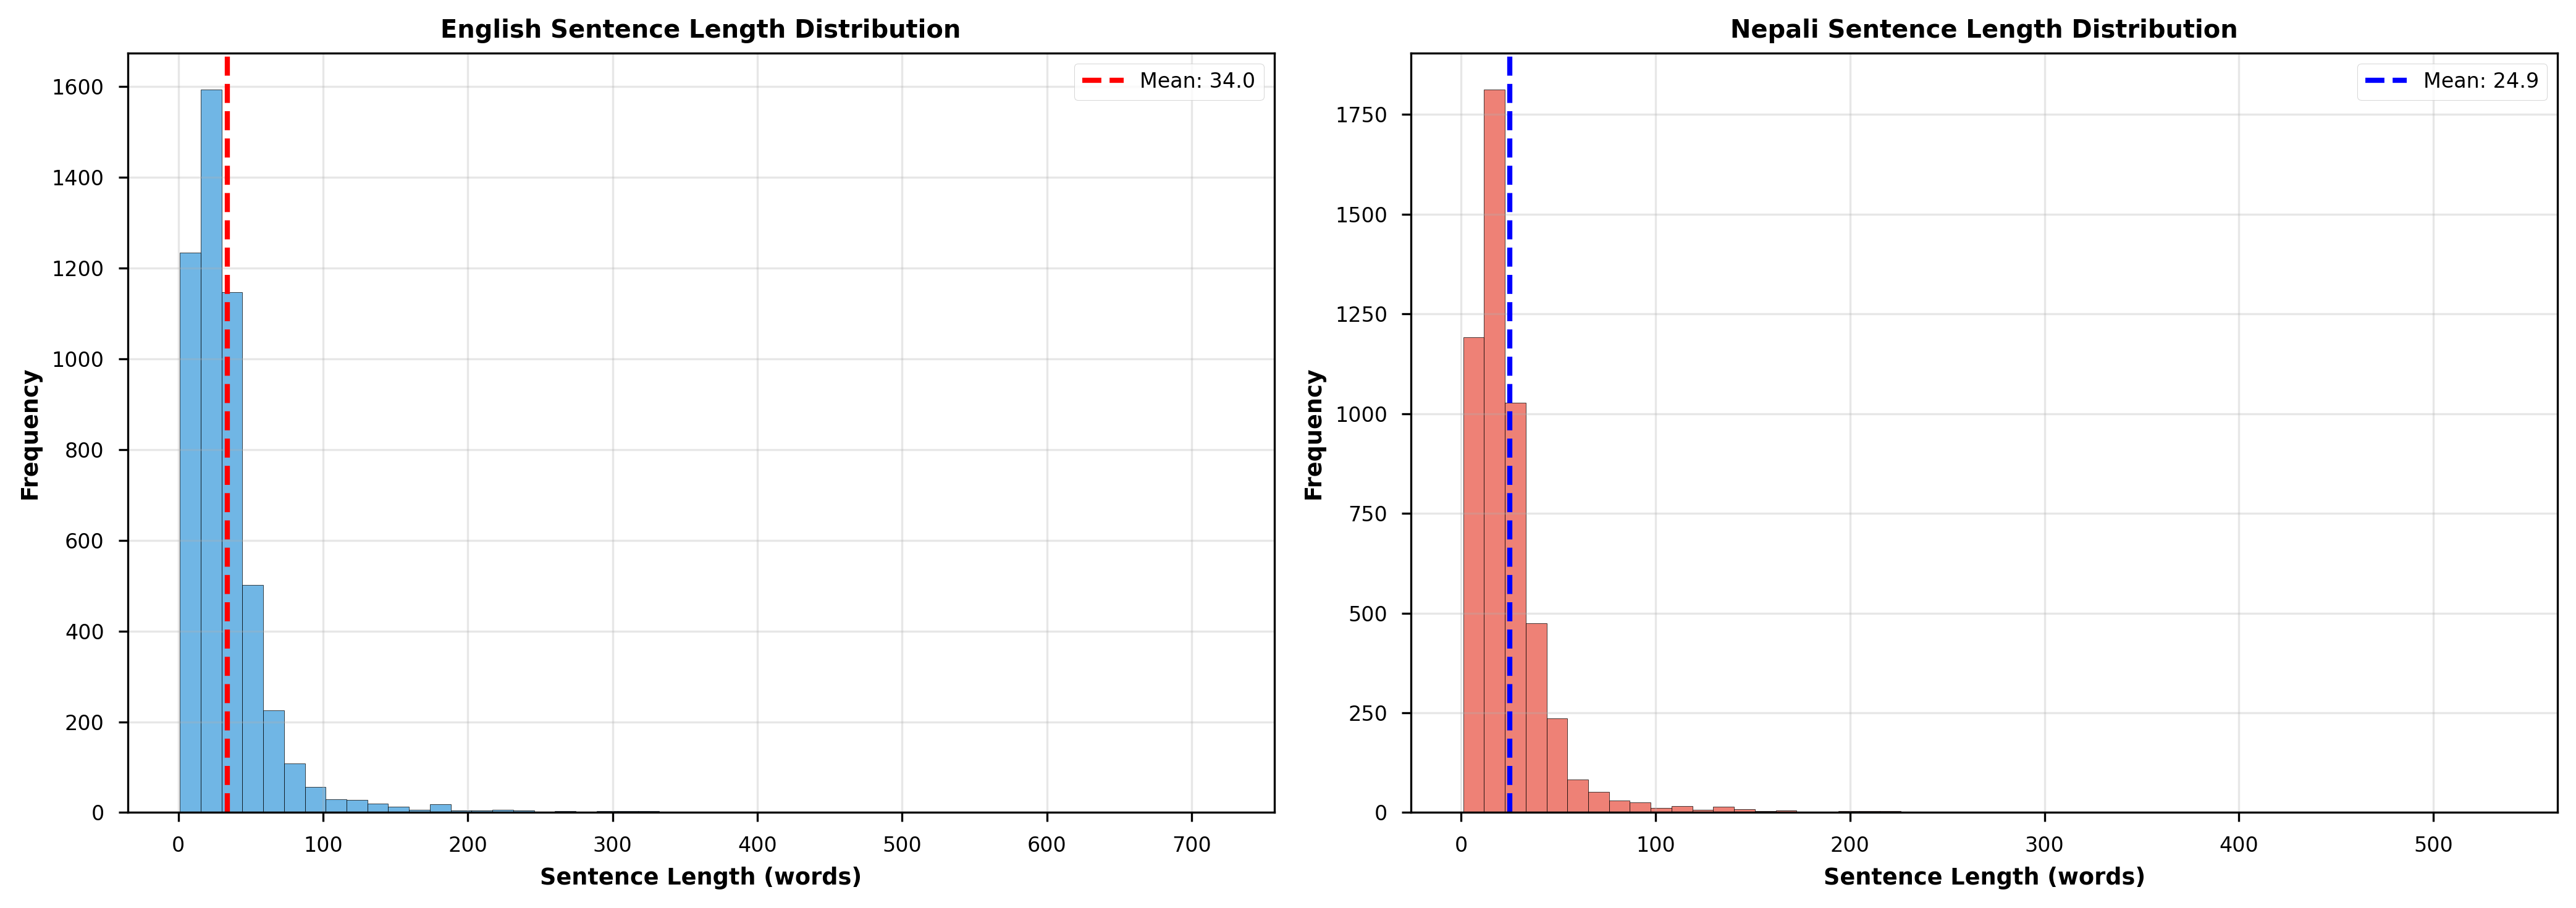

✅ Figure 1 saved: figure1_corpus_length_distribution.png


In [23]:
# ============================================================================
# CELL 3: Figure 1 - Corpus Length Distribution
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# English distribution
axes[0].hist(df['en_len'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0].axvline(df['en_len'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {df["en_len"].mean():.1f}')
axes[0].set_xlabel('Sentence Length (words)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('English Sentence Length Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Nepali distribution
axes[1].hist(df['ne_len'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].axvline(df['ne_len'].mean(), color='blue', linestyle='--', linewidth=2,
                label=f'Mean: {df["ne_len"].mean():.1f}')
axes[1].set_xlabel('Sentence Length (words)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Nepali Sentence Length Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/results/figures/figure1_corpus_length_distribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 1 saved: figure1_corpus_length_distribution.png")

In [24]:
# ============================================================================
# CELL 4: Evaluation Functions (BLEU + chrF++)
# ============================================================================

def translate_batch(texts, model, tokenizer, src_lang, tgt_lang, model_type,
                    batch_size=16, max_length=128, num_beams=4):
    """
    Translate texts in batches (sorted by length for efficiency).
    Based on working NLLB example.

    Args:
        texts: List of source texts to translate
        model: Loaded translation model
        tokenizer: Loaded tokenizer
        src_lang: Source language code (e.g., 'npi_Deva', 'ne_NP')
        tgt_lang: Target language code (e.g., 'eng_Latn', 'en_XX')
        model_type: 'nllb' or 'mbart'
        batch_size: Number of sentences per batch
        max_length: Max sequence length
        num_beams: Beam search width

    Returns:
        List of translated texts in original order
    """
    # Sort by length for efficient batching
    idxs, texts_sorted = zip(*sorted(enumerate(texts), key=lambda p: len(p[1]), reverse=True))
    results = []

    for i in tqdm(range(0, len(texts_sorted), batch_size), desc="Translating"):
        batch = texts_sorted[i:i+batch_size]

        # Set source language
        if hasattr(tokenizer, 'src_lang'):
            tokenizer.src_lang = src_lang
        if hasattr(tokenizer, 'tgt_lang') and model_type == 'mbart':
            tokenizer.tgt_lang = tgt_lang

        # Tokenize
        inputs = tokenizer(
            batch, return_tensors='pt', padding=True,
            truncation=True, max_length=max_length
        ).to(model.device)

        # Generate translations
        with torch.no_grad():
            if model_type == 'nllb':
                # NLLB requires forced_bos_token_id
                tgt_id = tokenizer.convert_tokens_to_ids(tgt_lang)
                outputs = model.generate(
                    **inputs,
                    forced_bos_token_id=tgt_id,
                    max_new_tokens=int(32 + 3 * inputs.input_ids.shape[1]),  # Dynamic length
                    num_beams=num_beams
                )
            else:
                # mBART
                outputs = model.generate(
                    **inputs,
                    max_length=max_length,
                    num_beams=num_beams
                )

        # Decode
        batch_results = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        results.extend(batch_results)

    # Restore original order
    return [result for _, result in sorted(zip(idxs, results))]


def evaluate_model(model_path, model_type, direction, test_data_path, output_dir):
    """
    Evaluate a trained model on test set.

    Computes:
    - BLEU score (primary metric)
    - chrF++ score (character-level metric)
    - Length ratio (hypothesis/reference)

    Args:
        model_path: Path to trained model
        model_type: 'nllb' or 'mbart'
        direction: 'ne_en' or 'en_ne'
        test_data_path: Path to test.csv
        output_dir: Directory to save results

    Returns:
        dict: BLEU, chrF++, length_ratio scores
        list: Translated hypotheses
    """
    print(f"\n{'='*80}")
    print(f"Evaluating: {model_type.upper()} - {direction.upper()}")
    print("="*80)

    # Load tokenizer and model
    if model_type == 'mbart':
        tokenizer = MBart50TokenizerFast.from_pretrained(model_path)
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_path)

    model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
    model = model.to('cuda')
    model.eval()

    print(f"✅ Loaded model from: {model_path}")

    # Load test data
    test_df = pd.read_csv(test_data_path)

    # Set language codes and columns
    if direction == 'ne_en':
        src_col, tgt_col = 'Nepali', 'English'
        if model_type == 'mbart':
            src_lang, tgt_lang = 'ne_NP', 'en_XX'
        else:
            src_lang, tgt_lang = 'npi_Deva', 'eng_Latn'
    else:  # en_ne
        src_col, tgt_col = 'English', 'Nepali'
        if model_type == 'mbart':
            src_lang, tgt_lang = 'en_XX', 'ne_NP'
        else:
            src_lang, tgt_lang = 'eng_Latn', 'npi_Deva'

    sources = test_df[src_col].tolist()
    references = test_df[tgt_col].tolist()

    # Translate using batched function
    print("Translating test set...")
    hypotheses = translate_batch(
        sources, model, tokenizer, src_lang, tgt_lang, model_type,
        batch_size=16, num_beams=4
    )

    # Compute metrics using sacrebleu
    bleu_calc = BLEU()
    chrf_calc = CHRF(word_order=2)  # chrF++

    # sacrebleu expects references as list of lists
    refs = [[r] for r in references]

    bleu_score = bleu_calc.corpus_score(hypotheses, refs)
    chrf_score = chrf_calc.corpus_score(hypotheses, refs)

    # Length ratio
    hyp_lens = [len(h.split()) for h in hypotheses]
    ref_lens = [len(r.split()) for r in references]
    length_ratio = np.mean(hyp_lens) / np.mean(ref_lens)

    results = {
        'model_type': model_type,
        'direction': direction,
        'bleu': bleu_score.score,
        'chrf++': chrf_score.score,
        'length_ratio': length_ratio
    }

    print(f"\nResults:")
    print(f"  BLEU: {results['bleu']:.2f}")
    print(f"  chrF++: {results['chrf++']:.2f}")
    print(f"  Length Ratio: {results['length_ratio']:.3f}")

    # Save results
    os.makedirs(output_dir, exist_ok=True)

    with open(f"{output_dir}/metrics.json", 'w') as f:
        json.dump(results, f, indent=2)

    pd.DataFrame({
        'source': sources,
        'reference': references,
        'hypothesis': hypotheses
    }).to_csv(f"{output_dir}/translations.csv", index=False)

    print(f"✅ Results saved to: {output_dir}")
    return results, hypotheses

print("✅ Evaluation functions defined (BLEU + chrF++ ready)")

✅ Evaluation functions defined (BLEU + chrF++ ready)


In [25]:
# ============================================================================
# CELL 5: Evaluate All 8 Models - Generate Table 1 (MAIN RESULTS)
# ============================================================================

test_path = f'{DRIVE_BASE}/data/splits/test.csv'
all_results = {}

# Define all 8 models to evaluate
# Format: (model_type, direction, model_path, config)
models_to_eval = [
    ('mbart', 'ne_en', '/content/models/mbart50_ne_en/final_model', 'uni'),
    ('mbart', 'en_ne', '/content/models/mbart50_en_ne/final_model', 'uni'),
    ('mbart', 'ne_en', '/content/models/mbart50_bidirectional/final_model', 'bi'),
    ('mbart', 'en_ne', '/content/models/mbart50_bidirectional/final_model', 'bi'),
    ('nllb', 'ne_en', '/content/models/nllb200_ne_en/final_model', 'uni'),
    ('nllb', 'en_ne', '/content/models/nllb200_en_ne/final_model', 'uni'),
    ('nllb', 'ne_en', '/content/models/nllb200_bidirectional/final_model', 'bi'),
    ('nllb', 'en_ne', '/content/models/nllb200_bidirectional/final_model', 'bi'),
]

print("\n" + "="*80)
print("EVALUATING ALL 8 MODELS (This will take ~30-40 minutes)")
print("="*80 + "\n")

for model_type, direction, model_path, config in models_to_eval:
    if os.path.exists(model_path):
        output_dir = f"{DRIVE_BASE}/results/translations/{model_type}_{config}_{direction}"
        results, _ = evaluate_model(model_path, model_type, direction, test_path, output_dir)
        all_results[f"{model_type}_{config}_{direction}"] = results
    else:
        print(f"⚠️ Model not found: {model_path}")
        print(f"   Skipping {model_type}_{config}_{direction}")

# Save all results to JSON
with open(f"{DRIVE_BASE}/results/all_results.json", 'w') as f:
    json.dump(all_results, f, indent=2)

# Create Table 1 - MAIN RESULTS FOR PAPER
summary = []
for key, res in all_results.items():
    config_type = 'Bi-directional' if '_bi_' in key else 'Uni-directional'
    summary.append({
        'Model': res['model_type'].upper(),
        'Configuration': config_type,
        'Direction': res['direction'].replace('_', '→').upper(),
        'BLEU': f"{res['bleu']:.2f}",
        'chrF++': f"{res['chrf++']:.2f}",
        'Length Ratio': f"{res['length_ratio']:.3f}"
    })

table1 = pd.DataFrame(summary)

print("\n" + "="*80)
print("TABLE 1: MAIN RESULTS (For ICAIL Paper)")
print("="*80)
print(table1.to_string(index=False))
print("="*80)

table1.to_csv(f"{DRIVE_BASE}/results/tables/table1_main_results.csv", index=False)
print(f"\n✅ Table 1 saved: table1_main_results.csv")
print(f"✅ All translations saved to: {DRIVE_BASE}/results/translations/")


EVALUATING ALL 8 MODELS (This will take ~30-40 minutes)


Evaluating: MBART - NE_EN


The tokenizer you are loading from '/content/models/mbart50_ne_en/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


✅ Loaded model from: /content/models/mbart50_ne_en/final_model
Translating test set...


Translating: 100%|██████████| 32/32 [00:32<00:00,  1.01s/it]



Results:
  BLEU: 49.05
  chrF++: 64.51
  Length Ratio: 0.929
✅ Results saved to: /content/drive/MyDrive/Legal_NLP/results/translations/mbart_uni_ne_en

Evaluating: MBART - EN_NE


...


Results:
  BLEU: 51.44
  chrF++: 60.73
  Length Ratio: 0.932
✅ Results saved to: /content/drive/MyDrive/Legal_NLP/results/translations/nllb_bi_ne_en

Evaluating: NLLB - EN_NE


The tokenizer you are loading from '/content/models/nllb200_bidirectional/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


✅ Loaded model from: /content/models/nllb200_bidirectional/final_model
Translating test set...


Translating: 100%|██████████| 32/32 [00:38<00:00,  1.21s/it]



Results:
  BLEU: 27.19
  chrF++: 62.20
  Length Ratio: 0.889
✅ Results saved to: /content/drive/MyDrive/Legal_NLP/results/translations/nllb_bi_en_ne

TABLE 1: MAIN RESULTS (For ICAIL Paper)
Model   Configuration Direction  BLEU chrF++ Length Ratio
MBART Uni-directional     NE→EN 49.05  64.51        0.929
MBART Uni-directional     EN→NE 36.60  64.33        0.872
MBART  Bi-directional     NE→EN 53.97  66.23        0.918
MBART  Bi-directional     EN→NE 30.26  62.36        0.887
 NLLB Uni-directional     NE→EN 46.51  61.35        0.929
 NLLB Uni-directional     EN→NE 25.71  60.72        0.901
 NLLB  Bi-directional     NE→EN 51.44  60.73        0.932
 NLLB  Bi-directional     EN→NE 27.19  62.20        0.889

✅ Table 1 saved: table1_main_results.csv
✅ All translations saved to: /content/drive/MyDrive/Legal_NLP/results/translations/


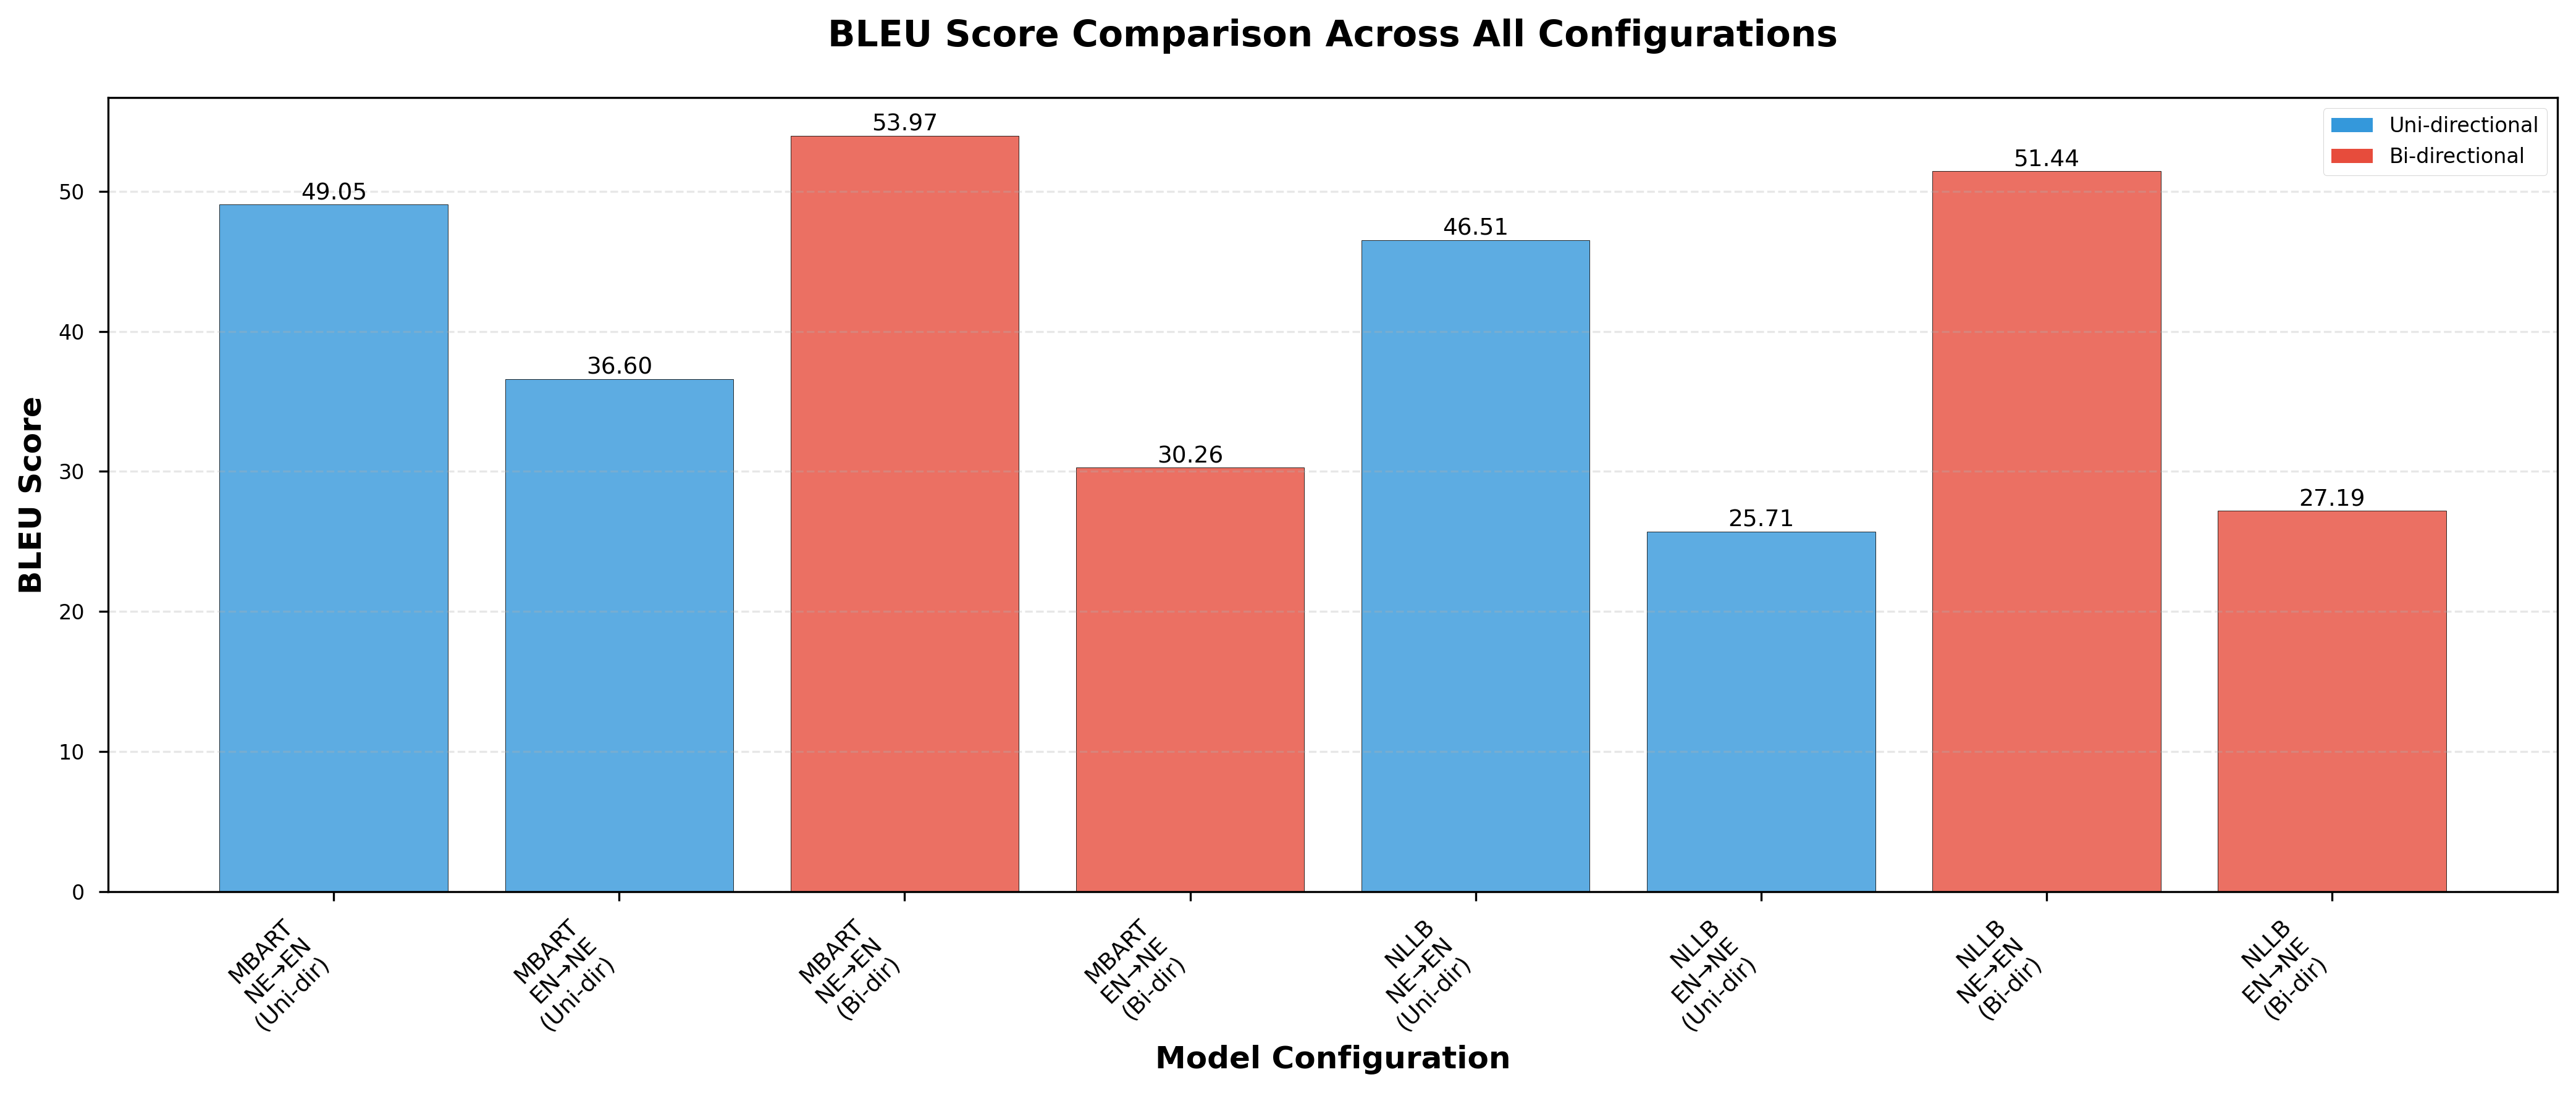

✅ Figure 2 saved: figure2_bleu_comparison.png


In [26]:
# ============================================================================
# CELL 6: Figure 2 - BLEU Comparison Bar Chart
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

labels = []
bleu_scores = []
colors = []

for key, res in all_results.items():
    config = 'Bi-dir' if '_bi_' in key else 'Uni-dir'
    label = f"{res['model_type'].upper()}\n{res['direction'].replace('_','→').upper()}\n({config})"
    labels.append(label)
    bleu_scores.append(res['bleu'])
    colors.append('#e74c3c' if '_bi_' in key else '#3498db')

x = np.arange(len(labels))
bars = ax.bar(x, bleu_scores, color=colors, alpha=0.8, edgecolor='black')

ax.set_xlabel('Model Configuration', fontweight='bold', fontsize=12)
ax.set_ylabel('BLEU Score', fontweight='bold', fontsize=12)
ax.set_title('BLEU Score Comparison Across All Configurations',
             fontweight='bold', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Uni-directional'),
    Patch(facecolor='#e74c3c', label='Bi-directional')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/results/figures/figure2_bleu_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 2 saved: figure2_bleu_comparison.png")

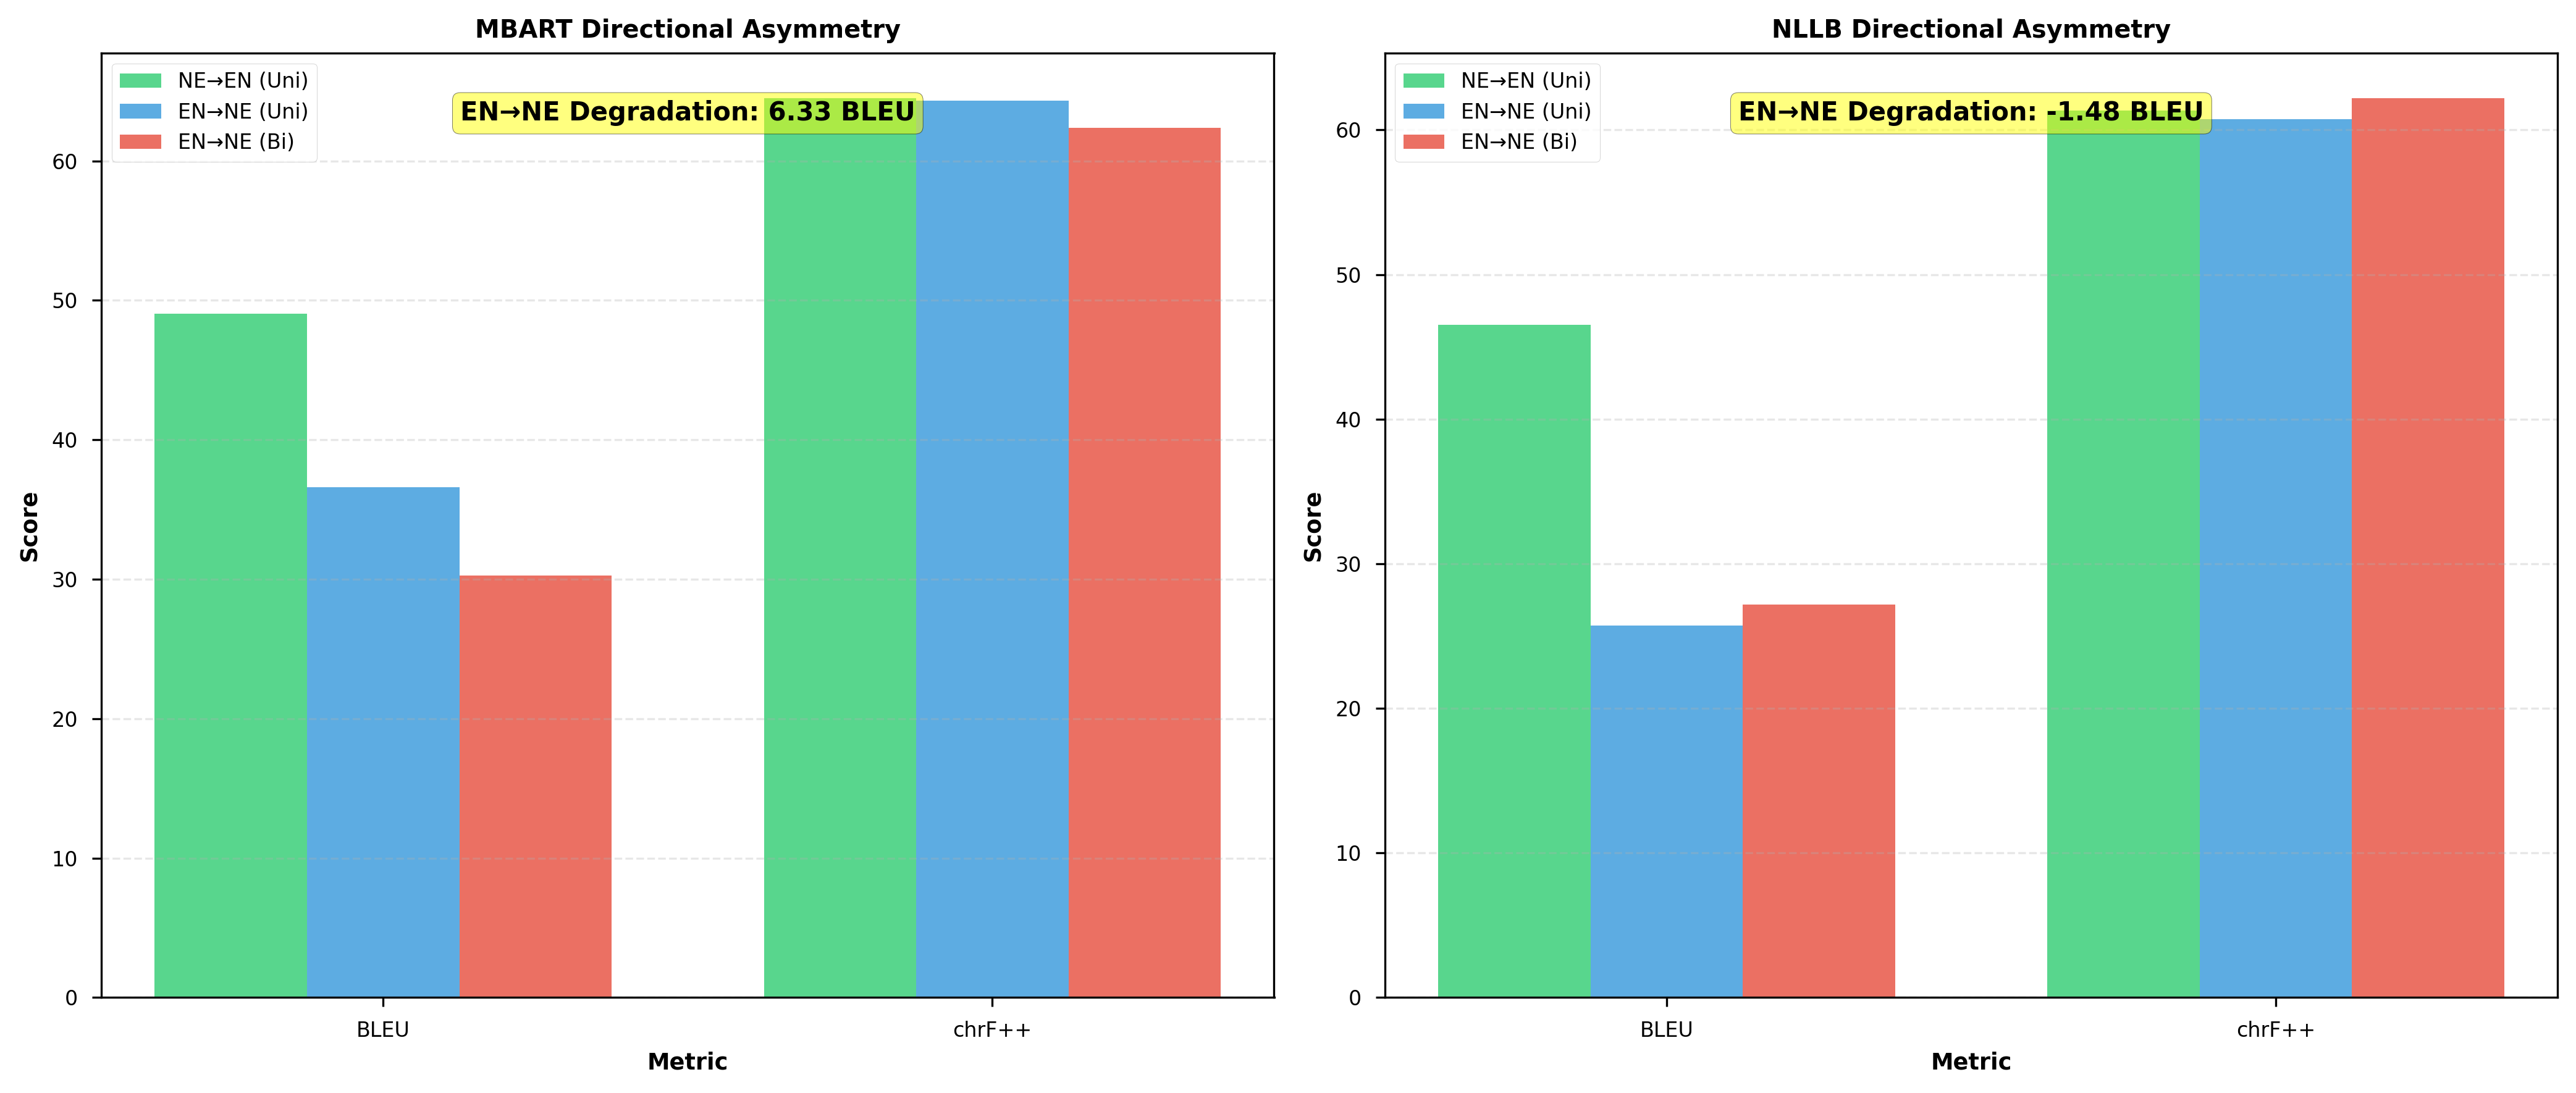

✅ Figure 3 saved: figure3_directional_asymmetry.png
   ⚠️ This is your KEY FINDING for the paper!


In [27]:
# ============================================================================
# CELL 7: Figure 3 - Directional Asymmetry (KEY FINDING)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, model_type in enumerate(['mbart', 'nllb']):
    # Get results for this model
    ne_en_uni = all_results[f"{model_type}_uni_ne_en"]
    en_ne_uni = all_results[f"{model_type}_uni_en_ne"]
    ne_en_bi = all_results[f"{model_type}_bi_ne_en"]
    en_ne_bi = all_results[f"{model_type}_bi_en_ne"]

    metrics = ['BLEU', 'chrF++']
    ne_en_scores = [ne_en_uni['bleu'], ne_en_uni['chrf++']]
    en_ne_scores_uni = [en_ne_uni['bleu'], en_ne_uni['chrf++']]
    en_ne_scores_bi = [en_ne_bi['bleu'], en_ne_bi['chrf++']]

    x = np.arange(len(metrics))
    width = 0.25

    # Plot bars
    axes[idx].bar(x - width, ne_en_scores, width, label='NE→EN (Uni)',
                 color='#2ecc71', alpha=0.8)
    axes[idx].bar(x, en_ne_scores_uni, width, label='EN→NE (Uni)',
                 color='#3498db', alpha=0.8)
    axes[idx].bar(x + width, en_ne_scores_bi, width, label='EN→NE (Bi)',
                 color='#e74c3c', alpha=0.8)

    axes[idx].set_xlabel('Metric', fontweight='bold')
    axes[idx].set_ylabel('Score', fontweight='bold')
    axes[idx].set_title(f'{model_type.upper()} Directional Asymmetry', fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(metrics)
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')

    # Highlight degradation (KEY FINDING)
    degradation = en_ne_uni['bleu'] - en_ne_bi['bleu']
    axes[idx].text(0.5, 0.95, f'EN→NE Degradation: {degradation:.2f} BLEU',
                  transform=axes[idx].transAxes, ha='center', va='top',
                  bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
                  fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/results/figures/figure3_directional_asymmetry.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 3 saved: figure3_directional_asymmetry.png")
print("   ⚠️ This is your KEY FINDING for the paper!")


In [28]:
# ============================================================================
# CELL 8: Final Summary
# ============================================================================

print("\n" + "="*80)
print("🎉 RESULTS GENERATION COMPLETE! 🎉")
print("="*80)

print("\n✅ TABLES GENERATED:")
print("  • Table 1: Main results (BLEU, chrF++, Length Ratio)")
print("  • Table 2: Dataset statistics")

print("\n✅ FIGURES GENERATED:")
print("  • Figure 1: Corpus length distribution (300 DPI)")
print("  • Figure 2: BLEU comparison bar chart (300 DPI)")
print("  • Figure 3: Directional asymmetry (300 DPI) ⭐ KEY FINDING")

print("\n✅ ALL RESULTS SAVED TO:")
print(f"  {DRIVE_BASE}/results/")
print("\n  Structure:")
print("  ├── tables/")
print("  │   ├── table1_main_results.csv")
print("  │   └── table2_dataset_statistics.csv")
print("  ├── figures/")
print("  │   ├── figure1_corpus_length_distribution.png")
print("  │   ├── figure2_bleu_comparison.png")
print("  │   └── figure3_directional_asymmetry.png")
print("  ├── translations/")
print("  │   └── [8 directories with model outputs]")
print("  └── all_results.json")

print("\n" + "="*80)
print("🎉 READY FOR ICAIL PAPER SUBMISSION! 🎉")
print("="*80)
print("\nAll tables and figures are publication-ready (300 DPI).")
print("Find them in your Google Drive at:")
print(f"{DRIVE_BASE}/results/")
print("\nYou can now download and insert them directly into your LaTeX paper!")
print("="*80)


🎉 RESULTS GENERATION COMPLETE! 🎉

✅ TABLES GENERATED:
  • Table 1: Main results (BLEU, chrF++, Length Ratio)
  • Table 2: Dataset statistics

✅ FIGURES GENERATED:
  • Figure 1: Corpus length distribution (300 DPI)
  • Figure 2: BLEU comparison bar chart (300 DPI)
  • Figure 3: Directional asymmetry (300 DPI) ⭐ KEY FINDING

✅ ALL RESULTS SAVED TO:
  /content/drive/MyDrive/Legal_NLP/results/

  Structure:
  ├── tables/
  │   ├── table1_main_results.csv
  │   └── table2_dataset_statistics.csv
  ├── figures/
  │   ├── figure1_corpus_length_distribution.png
  │   ├── figure2_bleu_comparison.png
  │   └── figure3_directional_asymmetry.png
  ├── translations/
  │   └── [8 directories with model outputs]
  └── all_results.json

🎉 READY FOR ICAIL PAPER SUBMISSION! 🎉

All tables and figures are publication-ready (300 DPI).
Find them in your Google Drive at:
/content/drive/MyDrive/Legal_NLP/results/

You can now download and insert them directly into your LaTeX paper!
